In [2]:
!pip install ipython-sql
%load_ext sql





ModuleNotFoundError: No module named 'pandas'

In [23]:
!pip install pandas matplotlib seaborn pysqlite3 scipy
import pandas as pd
import scipy.stats as stats


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 176.3 MB/s eta 0:00:0000:01


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import sqlite3

In [10]:
# that implements a self-contained, serverless zero configuration transactional SQL database engine.
conn = sqlite3.connect('McDonalds.db')
data= pd.read_csv('menu.csv')
data.to_sql('MCDONALDS_NUTRTION', conn)
sql_sentence = """
SELECT * FROM MCDONALDS_NUTRTION
"""
df = pd.read_sql(sql_sentence, conn)


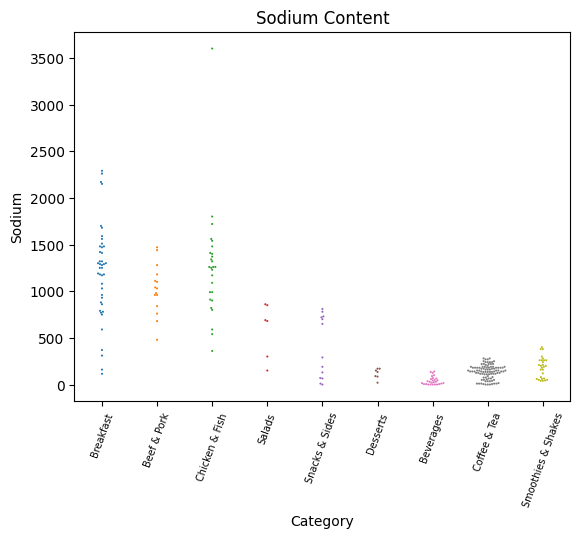

In [12]:
### categorical Scatter plotts
plot = sns.swarmplot(x="Category", y="Sodium", data=df, size=1.5, hue="Category")
plt.setp(plot.get_xticklabels(), rotation = 70, fontsize=7)
plt.title('Sodium Content')
plt.show()


Which food item has maximum sodium content?

In [13]:
df['Sodium'].describe()

count     260.000000
mean      495.750000
std       577.026323
min         0.000000
25%       107.500000
50%       190.000000
75%       865.000000
max      3600.000000
Name: Sodium, dtype: float64

In [14]:
df['Sodium'].idxmax()

82

In [17]:
df.at[82,'Item']

'Chicken McNuggets (40 piece)'

In [18]:
df.at[df['Sodium'].idxmax(),'Item']

'Chicken McNuggets (40 piece)'

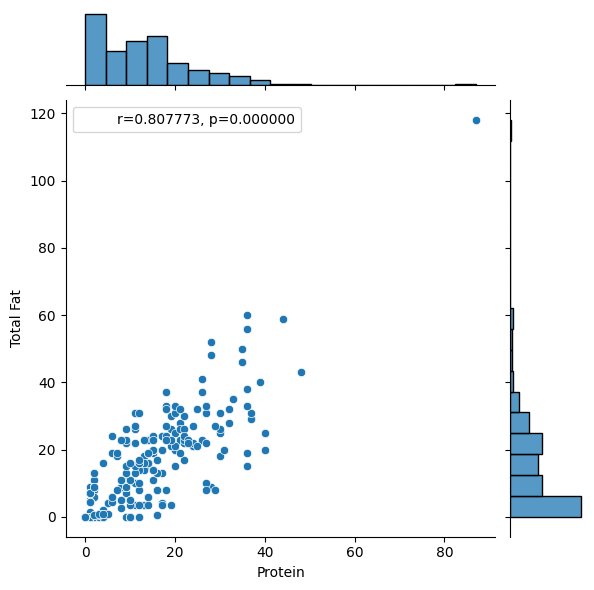

In [25]:
plot = sns.jointplot(data=df, x="Protein", y='Total Fat')
r, p = stats.pearsonr(df['Protein'], df['Total Fat'])
# if you choose to write your own legend, then you should adjust the properties then
phantom, = plot.ax_joint.plot([], [], linestyle="", alpha=0)
# here graph is not a ax but a joint grid, so we access the axis through ax_joint method

plot.ax_joint.legend([phantom],['r={:f}, p={:f}'.format(r,p)])
plt.show()

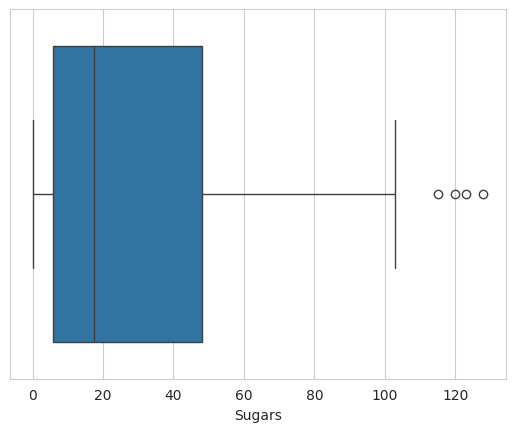

In [29]:
plot = sns.set_style("whitegrid")
ax = sns.boxplot(x=df['Sugars'])
plt.show()

In [31]:
df.at[df['Sugars'].idxmax(),'Item']

'McFlurry with M&M’s Candies (Medium)'

In [40]:
filtrados = df[df['Sugars'] > 110]
filtrados[['Item','Sugars']]

,Item,Sugars
246,Strawberry Shake (Large),123
249,Chocolate Shake (Large),120
251,Shamrock Shake (Large),115
253,McFlurry with M&M’s Candies (Medium),128
